mx01316a00.25__mearem_welev_lvl3_lvl3.parquet
mx01316a15.25__mearem_welev_lvl3_lvl3.parquet
mx01316a30.25__mearem_welev_lvl3_lvl3.parquet
mx01316a45.25__mearem_welev_lvl3_lvl3.parquet
mx01316b00.25__mearem_welev_lvl3_lvl3.parquet
mx01316b15.25__mearem_welev_lvl3_lvl3.parquet
mx01316b30.25__mearem_welev_lvl3_lvl3.parquet
mx01316b45.25__mearem_welev_lvl3_lvl3.parquet
mx01316c00.25__mearem_welev_lvl3_lvl3.parquet
mx01316c15.25__mearem_welev_lvl3_lvl3.parquet
mx01316c30.25__mearem_welev_lvl3_lvl3.parquet
mx01316c45.25__mearem_welev_lvl3_lvl3.parquet
mx01316d00.25__mearem_welev_lvl3_lvl3.parquet
mx01316d15.25__mearem_welev_lvl3_lvl3.parquet
mx01316d30.25__mearem_welev_lvl3_lvl3.parquet
mx01316d45.25__mearem_welev_lvl3_lvl3.parquet
mx01316e00.25__mearem_welev_lvl3_lvl3.parquet
mx01316e15.25__mearem_welev_lvl3_lvl3.parquet
mx01316e30.25__mearem_welev_lvl3_lvl3.parquet
mx01316e45.25__mearem_welev_lvl3_lvl3.parquet
mx01316f00.25__mearem_welev_lvl3_lvl3.parquet
mx01316f15.25__mearem_welev_lvl3_l

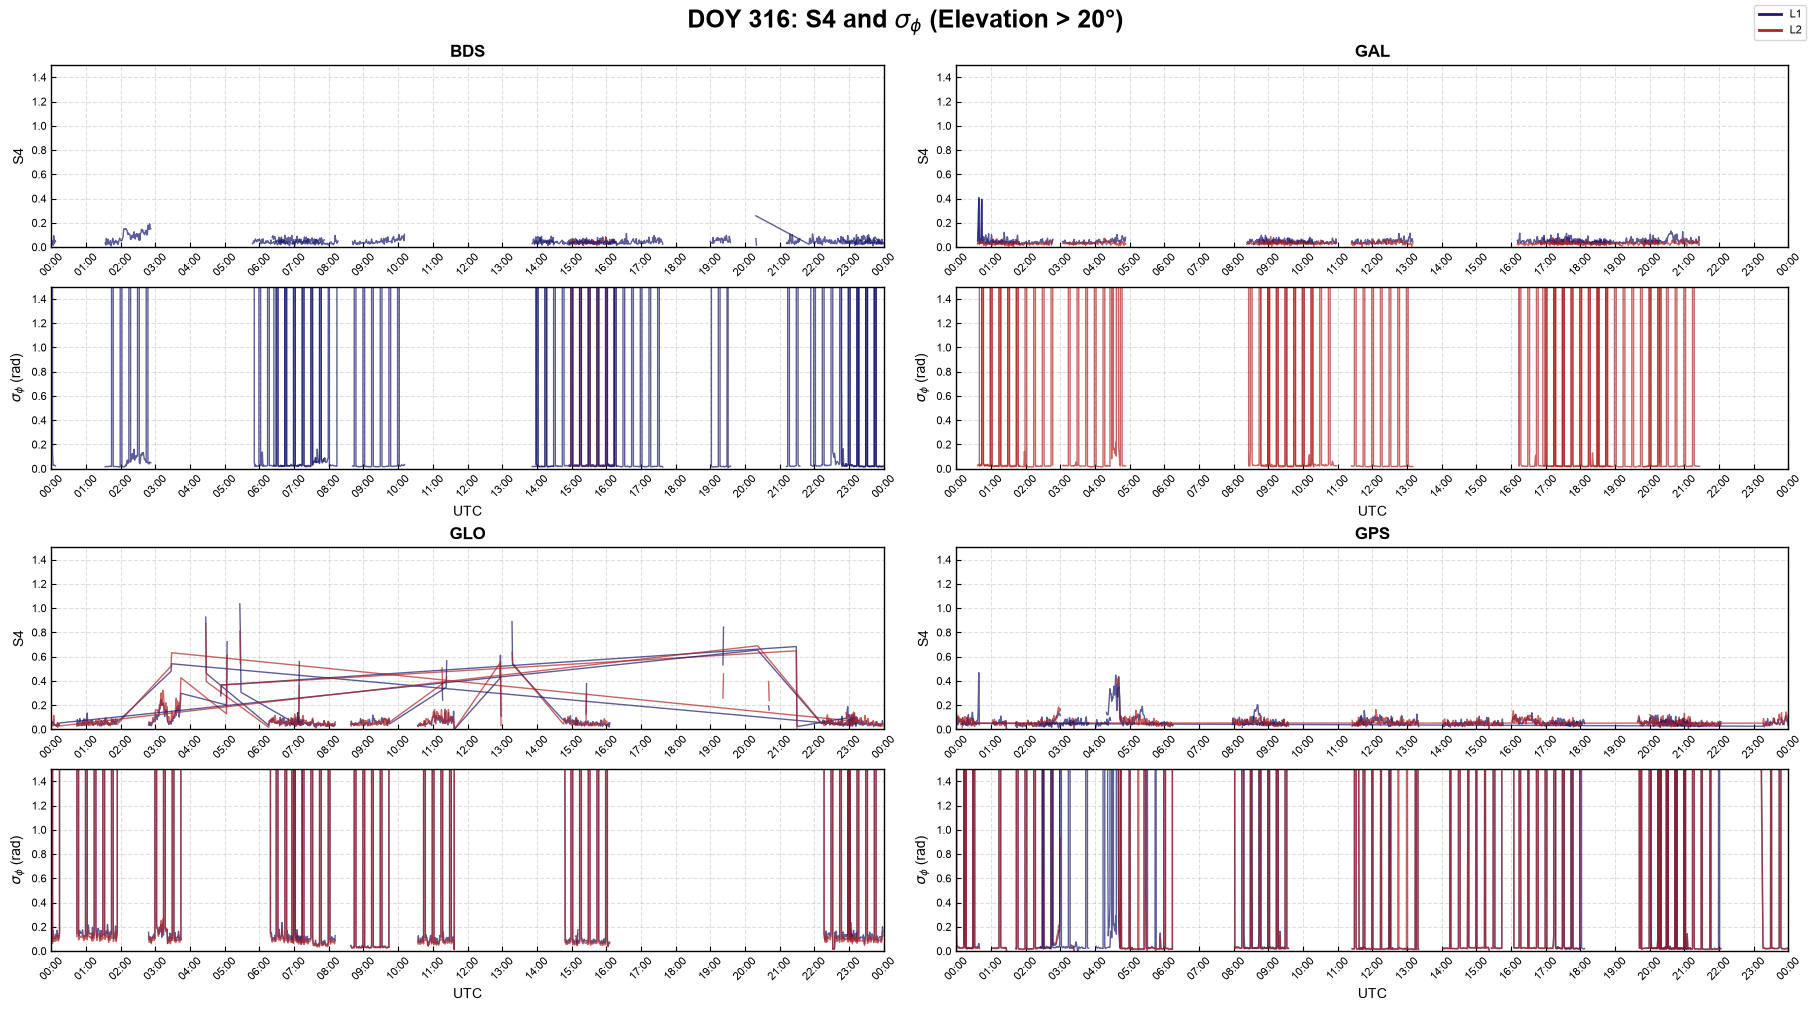

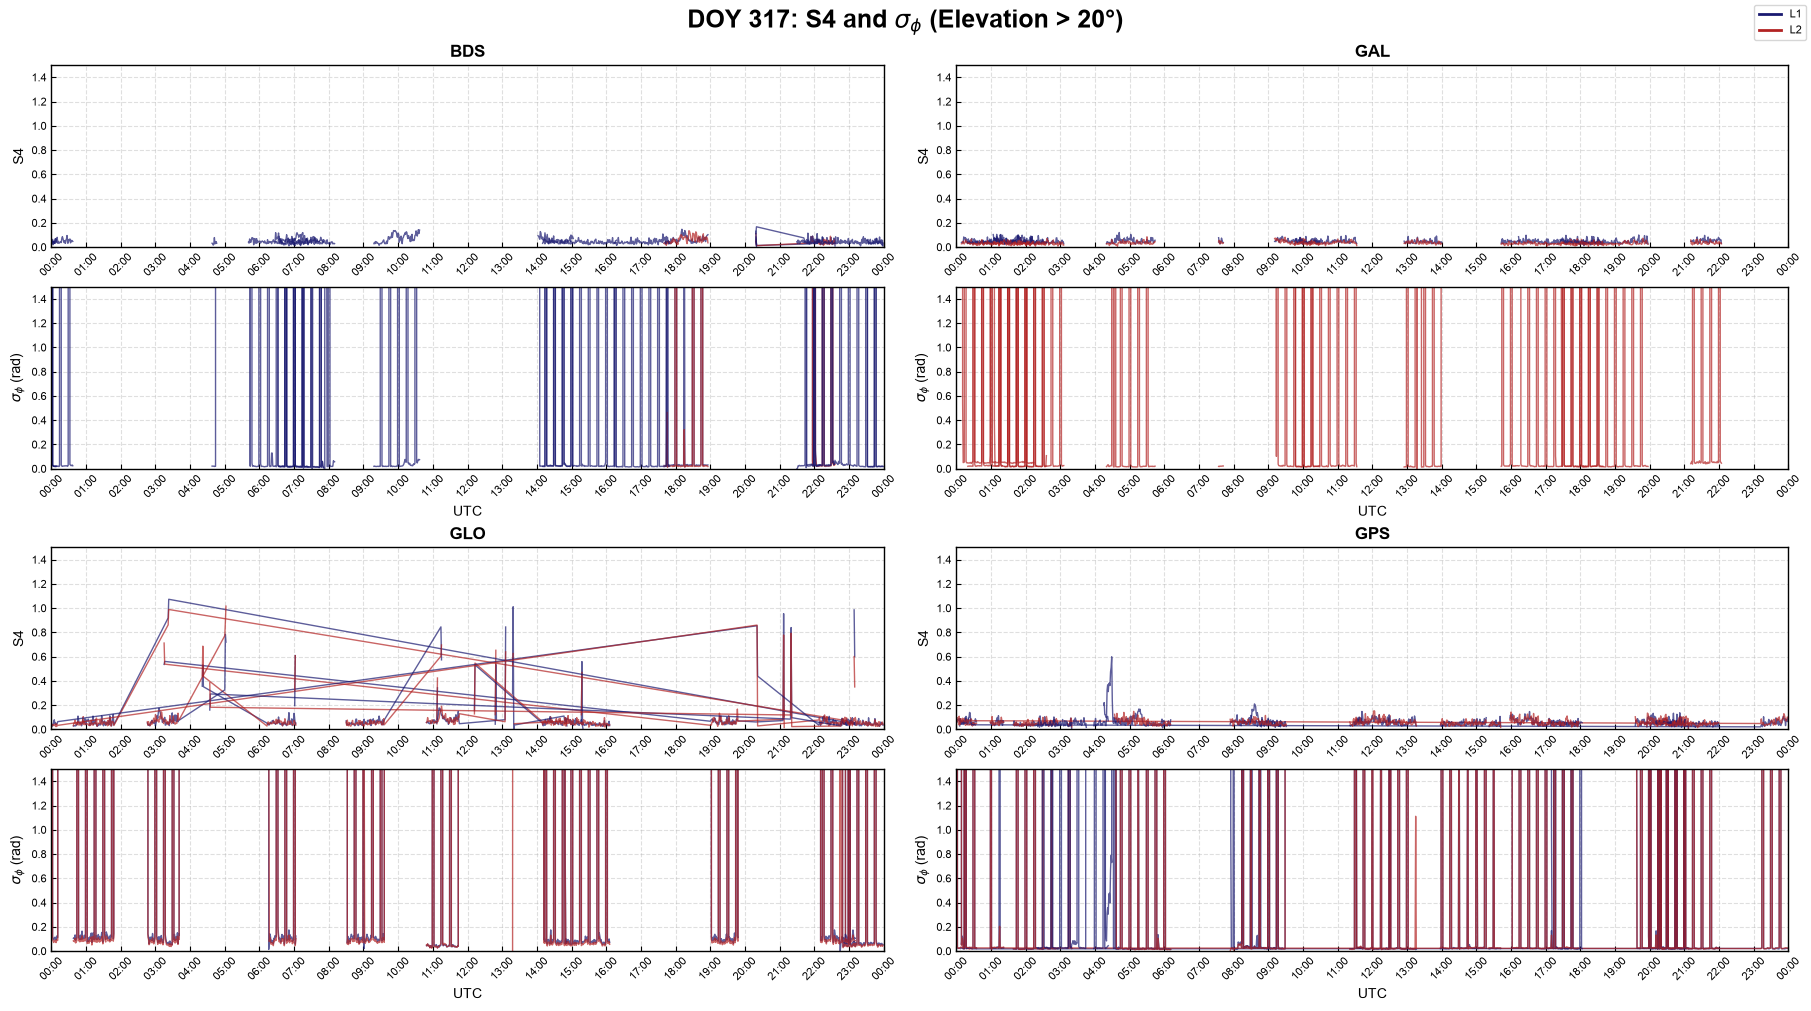

In [2]:
import math
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ==========================================================
# Folder containing all Level-3 parquet files
# ==========================================================

data_dir = Path("/Users/dal674840/Downloads/lvl3_parquet")


# ==========================================================
# Read all files
# ==========================================================

files = sorted(data_dir.glob("*_lvl3*.parquet"))

dfs = []

for f in files:

    print(f.name)

    df = pd.read_parquet(f)

    df["minbin"] = pd.to_datetime(df["minbin"])

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)


# ==========================================================
# Elevation filter
# ==========================================================

df = df[df["elevdeg"] > 20].copy()


# ==========================================================
# Add GPS Day (DOY)
# ==========================================================

df["doy"] = df["minbin"].dt.dayofyear


# ==========================================================
# Plot settings
# ==========================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

L1_COLOR = "midnightblue"
L2_COLOR = "firebrick"


# ==========================================================
# Plot each day separately
# ==========================================================

for day in [316, 317]:

    day_df = df[df["doy"] == day].copy()

    if len(day_df) == 0:
        print(f"No data for DOY {day}")
        continue

    constellations = sorted(day_df["cons"].unique())

    ncols = 2
    nrows = math.ceil(len(constellations) / ncols)

    fig, axes = plt.subplots(
        nrows * 2,
        ncols,
        figsize=(18, 5 * nrows),
        constrained_layout=True,
    )

    axes = axes.reshape(nrows * 2, ncols)

    # ------------------------------------------------------

    for i, cons in enumerate(constellations):

        row = (i // ncols) * 2
        col = i % ncols

        ax1 = axes[row, col]
        ax2 = axes[row + 1, col]

        cons_df = day_df[day_df["cons"] == cons]

        satellites = sorted(cons_df["satellite"].unique())

        # ------------------------------------------
        # Plot every satellite
        # ------------------------------------------

        for sat in satellites:

            sat_df = (
                cons_df[cons_df["satellite"] == sat]
                .sort_values("minbin")
            )

            # ---------- S4 ----------

            ax1.plot(
                sat_df["minbin"],
                sat_df["s4_1"],
                color=L1_COLOR,
                linewidth=1,
                alpha=0.7,
            )

            ax1.plot(
                sat_df["minbin"],
                sat_df["s4_2"],
                color=L2_COLOR,
                linewidth=1,
                alpha=0.7,
            )

            # ------- Sigma Phi -------

            ax2.plot(
                sat_df["minbin"],
                sat_df["sigma_phi_1"],
                color=L1_COLOR,
                linewidth=1,
                alpha=0.7,
            )

            ax2.plot(
                sat_df["minbin"],
                sat_df["sigma_phi_2"],
                color=L2_COLOR,
                linewidth=1,
                alpha=0.7,
            )

        # ------------------------------------------

        ax1.set_title(cons, fontweight="bold")
        ax1.set_ylabel("S4")
        ax1.set_ylim(0, 1.5)
        ax1.grid(True, linestyle="--", alpha=0.4)

        ax2.set_ylabel(r"$\sigma_\phi$ (rad)")
        ax2.set_xlabel("UTC")
        ax2.set_ylim(0, 1.5)
        ax2.grid(True, linestyle="--", alpha=0.4)

        # ------------------------------------------
        # 24-hour x-axis
        # ------------------------------------------

        start = pd.Timestamp(day_df["minbin"].min().date())

        end = start + pd.Timedelta(days=1)

        locator = mdates.HourLocator(interval=1)
        formatter = mdates.DateFormatter("%H:%M")

        for ax in [ax1, ax2]:

            ax.set_xlim(start, end)

            ax.xaxis.set_major_locator(locator)

            ax.xaxis.set_major_formatter(formatter)

        plt.setp(ax1.get_xticklabels(), rotation=45)
        plt.setp(ax2.get_xticklabels(), rotation=45)

    # ------------------------------------------------------
    # Remove empty axes
    # ------------------------------------------------------

    total = nrows * ncols

    for j in range(len(constellations), total):

        row = (j // ncols) * 2
        col = j % ncols

        fig.delaxes(axes[row, col])
        fig.delaxes(axes[row + 1, col])

    # ------------------------------------------------------

    handles = [
        plt.Line2D([], [], color=L1_COLOR, lw=2, label="L1"),
        plt.Line2D([], [], color=L2_COLOR, lw=2, label="L2"),
    ]

    fig.legend(
        handles=handles,
        loc="upper right",
        frameon=True,
    )

    fig.suptitle(
        f"DOY {day}: S4 and $\\sigma_\\phi$ (Elevation > 20°)",
        fontsize=18,
        fontweight="bold",
    )

    plt.savefig(
        f"DOY_{day}_constellations_S4_sigma_phi.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()